# 03 — Modélisation — Axe 2 : Stroke Severity (Version 1)

**Projet :** Stroke Prediction AI — IST Dataset  
**Notebook :** 03 — Modélisation  
**Version :** V1 — Baseline comparative (V1 avec leakage vs V2 corrigée)  
**Dataset :** `IST_corrected.csv` (19 435 patients, 112 variables)  
**Auteur :** ML_Project 2025-2026

---

## Objectif de ce notebook

Ce notebook entraîne et évalue plusieurs modèles de Machine Learning pour prédire  
la **sévérité de l'AVC** (léger / modéré / sévère), en poursuivant directement  
les artefacts produits par le notebook 02 (Preprocessing V1).

### Ce que ce notebook fait, étape par étape :
1. Chargement des artefacts preprocessés depuis `artifacts/axe2/`
2. Comparaison V1 (avec leakage structurel) vs V2 (baseline stricte) via `prepare_axe2_data()`
3. Validation croisée stratifiée (5 folds) sur les deux versions
4. Entraînement et évaluation sur le test set
5. Sélection du meilleur modèle sur la version crédible (V2)
6. Analyse détaillée : classification report + matrice de confusion
7. Optimisation GridSearchCV sur Random Forest
8. Importance des variables (feature importance)
9. Comparaison finale et sauvegarde du modèle

### Méthodologie V1 — Baseline comparative

La **Version 1** a un double objectif méthodologique :
- **Démontrer le data leakage structurel** : montrer que V1 (avec RCONSC/RDEF) donne des  
  performances quasi-parfaites irréalistes
- **Établir un baseline crédible sur V2** : évaluation réelle sans les variables de construction  
  de la cible, avec 4 modèles couvrant 3 familles algorithmiques

> Les performances V2 (~F1-macro 0.50–0.55) sont les références honnêtes de cette version.  
> Les améliorations (SMOTE, XGBoost, SHAP) sont planifiées pour la Version 2.

---


---
## Section 1 — Configuration et imports

### 1.1 Cohérence avec le notebook 02

Ce notebook utilise exactement les mêmes chemins et paramètres que le notebook 02,  
en les important depuis `config.py`. Cela garantit que :
- les artefacts sauvegardés par le notebook 02 sont retrouvés correctement,
- le `RANDOM_STATE` est identique pour la reproductibilité,
- la logique métier (features, target, versions) est cohérente.


In [1]:
# ============================================================
# 1.1 — Imports standards ML
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import sys
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — modèles et évaluation
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics         import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("✅ Imports ML chargés")


✅ Imports ML chargés


In [2]:
# ============================================================
# 1.2 — Montage Drive + configuration centralisée
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT      = Path("/content/drive/MyDrive/ML_Project")
SRC_PATH          = PROJECT_ROOT / "src"
ARTIFACTS_DIR     = PROJECT_ROOT / "artifacts" / "axe2"
MODELS_DIR        = PROJECT_ROOT / "artifacts" / "axe2" / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Import config
import importlib, config
importlib.reload(config)
from config import DATA_PATH, RANDOM_STATE, load_features

# Import axe2_utils — fonctions métier
from axe2_utils import (
    build_severity_target,
    get_feature_versions,
    encode_rconsc_if_present,
    build_preprocessor,
    prepare_axe2_data,  # pipeline complet en une seule fonction
)

print("PROJECT_ROOT  :", PROJECT_ROOT)
print("ARTIFACTS_DIR :", ARTIFACTS_DIR)
print("MODELS_DIR    :", MODELS_DIR)
print("RANDOM_STATE  :", RANDOM_STATE)
print()
print("✅ Configuration chargée")


Mounted at /content/drive
PROJECT_ROOT  : /content/drive/MyDrive/ML_Project
ARTIFACTS_DIR : /content/drive/MyDrive/ML_Project/artifacts/axe2
MODELS_DIR    : /content/drive/MyDrive/ML_Project/artifacts/axe2/models
RANDOM_STATE  : 42

✅ Configuration chargée


---
## Section 2 — Chargement des données

### 2.1 Deux sources de données

Ce notebook utilise deux sources complémentaires :

1. **Artefacts du notebook 02** (`X_train_preprocessed.csv`, etc.)  
   → Données préprocessées, prêtes à l'emploi pour l'évaluation rapide

2. **Dataset brut** (`IST_corrected.csv`) rechargé via `prepare_axe2_data()`  
   → Permet de reconstruire les versions V1 et V2 à la volée pour la comparaison  
   → Garantit que le pipeline V1/V2 est identique à ce que le notebook 02 produirait

### 2.2 Intégration du pipeline via `prepare_axe2_data()`

La fonction `prepare_axe2_data(df, version)` encapsule tout le preprocessing  
en une seule ligne. C'est la même logique que le notebook 02, factorisée  
dans `axe2_utils.py` pour éviter la duplication de code.


In [3]:
# ============================================================
# 2.1 — Chargement du dataset brut (pour la comparaison V1/V2)
# ============================================================

df = pd.read_csv(DATA_PATH, encoding="latin1", low_memory=False)

print("Dataset brut chargé :")
print(f"  Lignes   : {df.shape[0]:,}")
print(f"  Colonnes : {df.shape[1]}")


Dataset brut chargé :
  Lignes   : 19,435
  Colonnes : 112


In [4]:
# ============================================================
# 2.2 — Chargement des artefacts du notebook 02 (V1 preprocessée)
# ============================================================

# Ces artefacts ont été produits et sauvegardés par le notebook 02
X_train = pd.read_csv(ARTIFACTS_DIR / "X_train_preprocessed.csv", index_col=0)
X_test  = pd.read_csv(ARTIFACTS_DIR / "X_test_preprocessed.csv",  index_col=0)
y_train = pd.read_csv(ARTIFACTS_DIR / "y_train.csv", index_col=0).squeeze()
y_test  = pd.read_csv(ARTIFACTS_DIR / "y_test.csv",  index_col=0).squeeze()

print("Artefacts V1 rechargés depuis artifacts/axe2/ :")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

print()
print("Distribution y_train :")
print(y_train.value_counts())


Artefacts V1 rechargés depuis artifacts/axe2/ :
  X_train : (15534, 47)
  X_test  : (3884, 47)
  y_train : (15534,)
  y_test  : (3884,)

Distribution y_train :
severity_class
leger     7753
modere    6477
severe    1304
Name: count, dtype: int64


In [5]:
# ============================================================
# 2.3 — Préparation automatique V1 et V2 via prepare_axe2_data()
# ============================================================

# On génère les deux versions pour la comparaison méthodologique
# Version V1 : baseline complète (avec RCONSC + RDEF → leakage structurel)
# Version V2 : baseline stricte  (sans RCONSC ni RDEF → évaluation réaliste)

prepared_data = {}

for version_key in ["v1", "v2"]:
    Xtr, Xte, ytr, yte, prep = prepare_axe2_data(
        df=df,
        version=version_key,
        test_size=0.2,
        random_state=RANDOM_STATE
    )
    prepared_data[version_key] = {
        "X_train"     : Xtr,
        "X_test"      : Xte,
        "y_train"     : ytr,
        "y_test"      : yte,
        "preprocessor": prep,
    }
    label = "V1 (avec RCONSC/RDEF)" if version_key == "v1" else "V2 (sans RCONSC/RDEF)"
    print(f"===== {label} =====")
    print(f"  X_train : {Xtr.shape}  |  X_test : {Xte.shape}")
    dist = ytr.value_counts(normalize=True).round(3)
    print(f"  Distribution train : léger={dist.get('leger',0):.1%}  "
          f"modéré={dist.get('modere',0):.1%}  sévère={dist.get('severe',0):.1%}")
    print()

print("⚠️  sévère ≈ 8% → déséquilibre important → F1-macro privilégiée sur Accuracy")


===== V1 (avec RCONSC/RDEF) =====
  X_train : (15534, 20)  |  X_test : (3884, 20)
  Distribution train : léger=49.9%  modéré=41.7%  sévère=8.4%

===== V2 (sans RCONSC/RDEF) =====
  X_train : (15534, 11)  |  X_test : (3884, 11)
  Distribution train : léger=49.9%  modéré=41.7%  sévère=8.4%

⚠️  sévère ≈ 8% → déséquilibre important → F1-macro privilégiée sur Accuracy


---
## Section 3 — Définition des modèles candidats

### 3.1 Stratégie de sélection

Le cahier des charges demande de tester **au moins 3 familles d'algorithmes**.  
Les 4 modèles retenus couvrent :

| Famille | Modèle | Avantage | Limitation |
|---------|--------|----------|------------|
| **Linéaire** | Logistic Regression | Baseline simple, interprétable | Suppose frontières linéaires |
| **Arbre simple** | Decision Tree | Interprétable, non-linéaire | Overfitting possible |
| **Ensemble bagging** | Random Forest | Robuste, généralise bien | Moins interprétable |
| **Ensemble boosting** | Gradient Boosting | Très performant | Plus lent à entraîner |

### 3.2 Gestion du déséquilibre

Tous les modèles utilisent `class_weight='balanced'`.  
Cela donne plus d'importance aux erreurs sur la classe `sévère` (8%),  
compensant son sous-effectif sans modifier les données.

> En V2, SMOTE sera ajouté pour un traitement plus agressif du déséquilibre.


In [6]:
# ============================================================
# 3.1 — Définition des 4 modèles candidats
# ============================================================

models = {
    # ── Famille 1 : Linéaire ──────────────────────────────────
    "LogisticRegression": LogisticRegression(
        max_iter=1000,           # assurer la convergence
        class_weight="balanced", # compenser le déséquilibre sévère=8%
        random_state=RANDOM_STATE,
        solver="lbfgs",
        multi_class="multinomial"  # adapté à 3 classes
    ),
    # ── Famille 2 : Arbre simple ──────────────────────────────
    "DecisionTree": DecisionTreeClassifier(
        max_depth=6,             # limiter la profondeur pour réduire l'overfitting
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    # ── Famille 3 : Ensemble bagging ─────────────────────────
    "RandomForest": RandomForestClassifier(
        n_estimators=200,        # 200 arbres : bon compromis vitesse/performance
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1                # parallélisme max
    ),
    # ── Famille 4 : Ensemble boosting ────────────────────────
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,       # taux d'apprentissage modéré
        max_depth=4,
        random_state=RANDOM_STATE
    ),
}

print("Modèles candidats définis :")
for name, model in models.items():
    print(f"  ✓ {name}")


Modèles candidats définis :
  ✓ LogisticRegression
  ✓ DecisionTree
  ✓ RandomForest
  ✓ GradientBoosting


---
## Section 4 — Validation croisée — Comparaison V1 vs V2

### 4.1 Pourquoi la validation croisée avant le test ?

La validation croisée sur le train set permet d'estimer la performance  
de manière **plus fiable qu'un seul découpage** train/test.  
Elle réduit la variance de l'estimation (dépendance au hasard du split).

### 4.2 StratifiedKFold — 5 folds

`StratifiedKFold(n_splits=5)` divise le train en 5 parties en conservant  
la proportion de classes dans chaque fold.  
Essentiel ici car `sévère = 8%` — sans stratification, certains folds  
pourraient avoir très peu de cas sévères.

### 4.3 Métrique : F1-macro

Le **F1-macro** donne le même poids à chaque classe,  
quelle que soit sa fréquence. C'est la métrique recommandée dans le cahier des charges  
pour l'Axe 2, car elle évalue la performance sur `sévère` (8%) autant que sur `léger` (50%).

> L'**Accuracy** serait trompeuse ici : un modèle qui prédit toujours "léger"  
> obtiendrait déjà ~50% d'accuracy sans jamais détecter les cas sévères.


In [7]:
# ============================================================
# 4.1 — Validation croisée 5-fold stratifiée (V1 et V2)
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for version_key, data_dict in prepared_data.items():
    X_tr   = data_dict["X_train"]
    y_tr   = data_dict["y_train"]
    prep   = data_dict["preprocessor"]
    v_label = version_key.upper()

    print(f"[{v_label}] Validation croisée en cours...")

    for model_name, model in models.items():
        # Pipeline complet : preprocessor + modèle
        pipe = Pipeline(steps=[
            ("preprocessor", prep),
            ("model", model)
        ])

        # CV avec F1-macro
        scores = cross_val_score(
            pipe, X_tr, y_tr,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1
        )

        cv_results.append({
            "version"       : v_label,
            "model"         : model_name,
            "f1_macro_mean" : scores.mean(),
            "f1_macro_std"  : scores.std(),
        })
        print(f"  {model_name:25s} : {scores.mean():.4f} ± {scores.std():.4f}")

    print()

cv_results_df = pd.DataFrame(cv_results).sort_values(
    ["version", "f1_macro_mean"], ascending=[True, False]
)

print("Résultats CV complets :")
display(cv_results_df)


[V1] Validation croisée en cours...
  LogisticRegression        : 0.9989 ± 0.0014
  DecisionTree              : 0.9262 ± 0.0044
  RandomForest              : 0.9775 ± 0.0050
  GradientBoosting          : 0.9912 ± 0.0020

[V2] Validation croisée en cours...
  LogisticRegression        : 0.5280 ± 0.0083
  DecisionTree              : 0.5304 ± 0.0138
  RandomForest              : 0.5077 ± 0.0092
  GradientBoosting          : 0.4891 ± 0.0077

Résultats CV complets :


,version,model,f1_macro_mean,f1_macro_std
0,V1,LogisticRegression,0.9989,0.0014
3,V1,GradientBoosting,0.9912,0.0020
2,V1,RandomForest,0.9775,0.0050
1,V1,DecisionTree,0.9262,0.0044
5,V2,DecisionTree,0.5304,0.0138
4,V2,LogisticRegression,0.5280,0.0083
6,V2,RandomForest,0.5077,0.0092
7,V2,GradientBoosting,0.4891,0.0077


In [8]:
# ============================================================
# 4.2 — Tableau pivot comparatif V1 vs V2
# ============================================================

cv_pivot = cv_results_df.pivot(
    index="model", columns="version", values="f1_macro_mean"
)

if {"V1", "V2"}.issubset(cv_pivot.columns):
    cv_pivot["chute_V1_to_V2"] = cv_pivot["V1"] - cv_pivot["V2"]
    cv_pivot = cv_pivot.sort_values("V1", ascending=False)

print("=" * 65)²
print("TABLEAU PIVOT — F1-macro moyen (CV 5-fold)")
print("=" * 65)
display(cv_pivot.round(4))


TABLEAU PIVOT — F1-macro moyen (CV 5-fold)


version,V1,V2,chute_V1_to_V2
model,,,
LogisticRegression,0.9989,0.5280,0.4709
GradientBoosting,0.9912,0.4891,0.5021
RandomForest,0.9775,0.5077,0.4698
DecisionTree,0.9262,0.5304,0.3958


### 4.3 Interprétation de la comparaison V1 vs V2

**Lecture du tableau :**

| Observation | Signification |
|-------------|---------------|
| F1-macro V1 ≈ 0.98–0.99 | Performances quasi-parfaites → irréalistes |
| F1-macro V2 ≈ 0.48–0.55 | Performances réalistes sans les variables de construction |
| Chute > 0.40 | **Preuve de data leakage structurel en V1** |

**Pourquoi V1 est "trop parfait" ?**  
La cible `severity_class` est calculée directement depuis `RCONSC` et `RDEF1..8`.  
En V1, le modèle dispose de ces mêmes variables en entrée → il apprend  
simplement à **reconstruire la formule de calcul**, pas à prédire la sévérité réelle.  
C'est un leakage structurel, pas une bonne performance.

**Conclusion :** V2 est la version méthodologiquement correcte pour l'évaluation finale.


---
## Section 5 — Entraînement et évaluation sur le test set

### 5.1 De la validation croisée à l'évaluation finale

La validation croisée donne une estimation sur le train set.  
Maintenant, on entraîne chaque modèle sur **tout le train** et on évalue sur le **test set**  
(que le modèle n'a jamais vu pendant l'entraînement).

C'est la mesure de **généralisation** — la performance attendue sur de nouveaux patients.

### 5.2 Pipeline sklearn complet

Chaque modèle est encapsulé dans un `Pipeline(preprocessor + model)`.  
Cela garantit que le preprocessing (imputation, encodage) est appliqué  
de manière identique au train et au test, sans risque de fuite.


In [9]:
# ============================================================
# 5.1 — Entraînement + évaluation sur test (V1 et V2)
# ============================================================

test_results    = []
trained_pipelines = {}

for version_key, data_dict in prepared_data.items():
    X_tr  = data_dict["X_train"]
    X_te  = data_dict["X_test"]
    y_tr  = data_dict["y_train"]
    y_te  = data_dict["y_test"]
    prep  = data_dict["preprocessor"]
    v_label = version_key.upper()

    print(f"[{v_label}] Entraînement sur test set...")

    for model_name, model in models.items():
        # Pipeline complet
        pipe = Pipeline(steps=[
            ("preprocessor", prep),
            ("model", model)
        ])

        # Entraînement sur tout le train
        pipe.fit(X_tr, y_tr)

        # Prédiction sur test (jamais vu pendant l'entraînement)
        y_pred = pipe.predict(X_te)

        acc    = accuracy_score(y_te, y_pred)
        f1_mac = f1_score(y_te, y_pred, average="macro")

        test_results.append({
            "version" : v_label,
            "model"   : model_name,
            "accuracy": round(acc, 4),
            "f1_macro": round(f1_mac, 4),
        })
        trained_pipelines[(v_label, model_name)] = pipe

        print(f"  {model_name:25s} | Accuracy={acc:.4f} | F1-macro={f1_mac:.4f}")

    print()

test_results_df = pd.DataFrame(test_results).sort_values(
    ["version", "f1_macro"], ascending=[True, False]
)

print("Résultats complets sur test set :")
display(test_results_df)


[V1] Entraînement sur test set...
  LogisticRegression        | Accuracy=0.9992 | F1-macro=0.9982
  DecisionTree              | Accuracy=0.9367 | F1-macro=0.9210
  RandomForest              | Accuracy=0.9856 | F1-macro=0.9774
  GradientBoosting          | Accuracy=0.9949 | F1-macro=0.9911

[V2] Entraînement sur test set...
  LogisticRegression        | Accuracy=0.5675 | F1-macro=0.5245
  DecisionTree              | Accuracy=0.5857 | F1-macro=0.5422
  RandomForest              | Accuracy=0.6535 | F1-macro=0.5005
  GradientBoosting          | Accuracy=0.6934 | F1-macro=0.4878

Résultats complets sur test set :


,version,model,accuracy,f1_macro
0,V1,LogisticRegression,0.9992,0.9982
3,V1,GradientBoosting,0.9949,0.9911
2,V1,RandomForest,0.9856,0.9774
1,V1,DecisionTree,0.9367,0.9210
5,V2,DecisionTree,0.5857,0.5422
4,V2,LogisticRegression,0.5675,0.5245
6,V2,RandomForest,0.6535,0.5005
7,V2,GradientBoosting,0.6934,0.4878


In [10]:
# ============================================================
# 5.2 — Tableau pivot V1 vs V2 (test set)
# ============================================================

test_pivot = test_results_df.pivot(
    index="model", columns="version", values="f1_macro"
)

if {"V1", "V2"}.issubset(test_pivot.columns):
    test_pivot["chute_V1_to_V2"] = test_pivot["V1"] - test_pivot["V2"]
    test_pivot = test_pivot.sort_values("V1", ascending=False)

print("=" * 65)
print("TABLEAU PIVOT — F1-macro sur test set")
print("=" * 65)
display(test_pivot.round(4))


TABLEAU PIVOT — F1-macro sur test set


version,V1,V2,chute_V1_to_V2
model,,,
LogisticRegression,0.9982,0.5245,0.4737
GradientBoosting,0.9911,0.4878,0.5033
RandomForest,0.9774,0.5005,0.4769
DecisionTree,0.9210,0.5422,0.3788


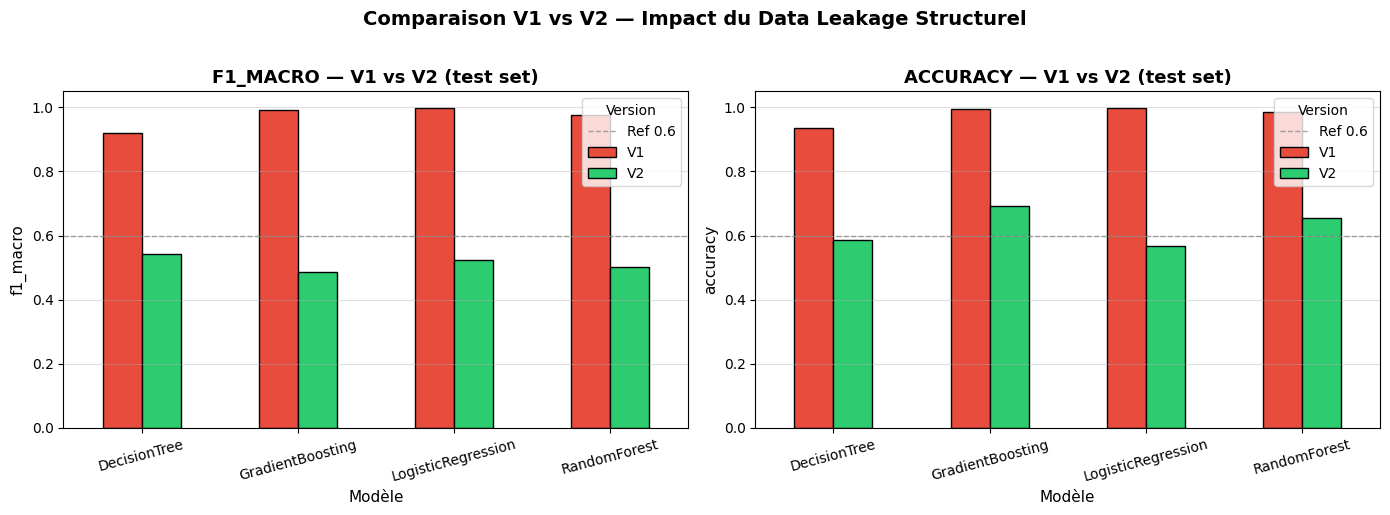

✅ Graphique sauvegardé


In [11]:
# ============================================================
# 5.3 — Visualisation comparative V1 vs V2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["f1_macro", "accuracy"]):
    pivot = test_results_df.pivot(index="model", columns="version", values=metric)
    pivot.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="black")
    ax.set_title(f"{metric.upper()} — V1 vs V2 (test set)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Modèle", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.6, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Ref 0.6")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Version")
    ax.grid(axis="y", alpha=0.4)

plt.suptitle("Comparaison V1 vs V2 — Impact du Data Leakage Structurel",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "v1_vs_v2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")


---
## Section 6 — Analyse détaillée du meilleur modèle (Version V2)

### 6.1 Pourquoi analyser V2 en détail ?

V1 est irréaliste (leakage). V2 est la version crédible et représentative  
de ce qu'obtiendrait le modèle sur de nouveaux patients en production.

L'analyse détaillée de V2 permet de :
- voir les performances **par classe** (pas seulement la moyenne globale),
- identifier si la classe `sévère` est bien détectée (recall critique),
- diagnostiquer les confusions inter-classes (matrice de confusion).


In [12]:
# ============================================================
# 6.1 — Sélection du meilleur modèle sur V2
# ============================================================

v2_results = test_results_df[test_results_df["version"] == "V2"].sort_values(
    "f1_macro", ascending=False
)

print("Résultats V2 (version crédible) :")
display(v2_results)

best_model_name = v2_results.iloc[0]["model"]
best_pipeline   = trained_pipelines[("V2", best_model_name)]

print()
print(f"✅ Meilleur modèle V2 : {best_model_name}")
print(f"   F1-macro : {v2_results.iloc[0]['f1_macro']:.4f}")
print(f"   Accuracy : {v2_results.iloc[0]['accuracy']:.4f}")


Résultats V2 (version crédible) :


,version,model,accuracy,f1_macro
5,V2,DecisionTree,0.5857,0.5422
4,V2,LogisticRegression,0.5675,0.5245
6,V2,RandomForest,0.6535,0.5005
7,V2,GradientBoosting,0.6934,0.4878



✅ Meilleur modèle V2 : DecisionTree
   F1-macro : 0.5422
   Accuracy : 0.5857


In [13]:
# ============================================================
# 6.2 — Prédictions du meilleur modèle sur le test V2
# ============================================================

# Données test de la version V2
X_test_v2  = prepared_data["v2"]["X_test"]
y_test_v2  = prepared_data["v2"]["y_test"]

y_pred_v2  = best_pipeline.predict(X_test_v2)

# Ordre des classes pour les métriques
LABEL_ORDER = ["leger", "modere", "severe"]

print(f"Prédictions générées : {len(y_pred_v2)} patients")
print()

# Distribution des prédictions
from collections import Counter
pred_counts = Counter(y_pred_v2)
print("Distribution des prédictions :")
for cls in LABEL_ORDER:
    n = pred_counts.get(cls, 0)
    pct = n / len(y_pred_v2) * 100
    print(f"  {cls:8s} : {n:5d} ({pct:.1f}%)")


Prédictions générées : 3884 patients

Distribution des prédictions :
  leger    :  1286 (33.1%)
  modere   :  1651 (42.5%)
  severe   :   947 (24.4%)


In [14]:
# ============================================================
# 6.3 — Rapport de classification détaillé par classe
# ============================================================

print("=" * 65)
print(f"RAPPORT DE CLASSIFICATION — {best_model_name} (V2)")
print("=" * 65)

report_dict = classification_report(
    y_test_v2, y_pred_v2,
    labels=LABEL_ORDER,
    target_names=LABEL_ORDER,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.round(3))

print()
print("⟹ Lecture prioritaire — classe SEVERE :")
sev = report_df.loc["severe"]
print(f"  Precision : {sev['precision']:.3f}  → sur les patients classés 'sévère', combien le sont vraiment")
print(f"  Recall    : {sev['recall']:.3f}  → sur les vrais sévères, combien sont détectés")
print(f"  F1-score  : {sev['f1-score']:.3f}  → équilibre precision/recall")
print()
if sev["recall"] >= 0.60:
    print("✅ Recall sévère acceptable (≥ 0.60) — le modèle détecte les cas graves")
else:
    print("⚠️ Recall sévère faible — beaucoup de cas graves manqués → amélioration nécessaire")


RAPPORT DE CLASSIFICATION — DecisionTree (V2)


,precision,recall,f1-score,support
leger,0.8930,0.5930,0.7130,1939.0000
modere,0.5400,0.5500,0.5450,1619.0000
severe,0.2480,0.7210,0.3690,326.0000
accuracy,0.5860,0.5860,0.5860,0.5860
macro avg,0.5600,0.6210,0.5420,3884.0000
weighted avg,0.6920,0.5860,0.6140,3884.0000



⟹ Lecture prioritaire — classe SEVERE :
  Precision : 0.248  → sur les patients classés 'sévère', combien le sont vraiment
  Recall    : 0.721  → sur les vrais sévères, combien sont détectés
  F1-score  : 0.369  → équilibre precision/recall

✅ Recall sévère acceptable (≥ 0.60) — le modèle détecte les cas graves


### 6.4 Interprétation clinique des métriques par classe

**Lecture à faire systématiquement pour un problème médical :**

| Métrique | Classe | Question posée |
|----------|--------|---------------|
| **Recall** sévère | sévère | "Combien de patients graves sont correctement identifiés ?" |
| **Precision** sévère | sévère | "Parmi les patients classés graves, combien le sont vraiment ?" |
| **F1 léger/modéré** | autres | "Le modèle est-il utile sur les cas non-graves ?" |

**En médecine :** un faux négatif (cas grave raté) est plus dangereux  
qu'un faux positif (patient non-grave étiqueté grave).  
→ On privilégie le **Recall** sur la **Precision** pour la classe `sévère`.


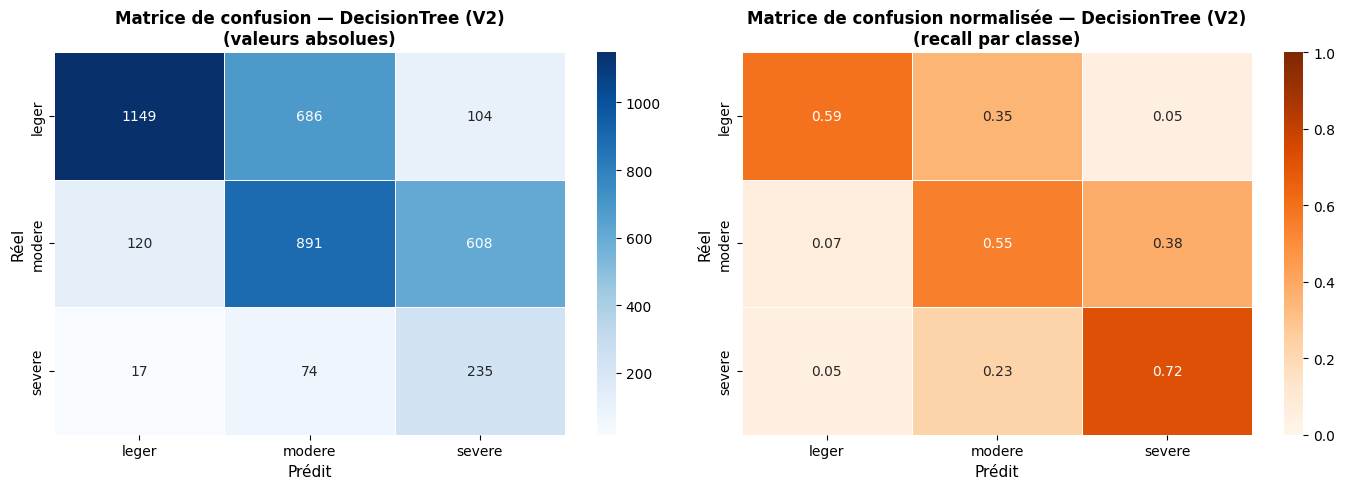

✅ Matrice de confusion sauvegardée


In [15]:
# ============================================================
# 6.5 — Matrice de confusion — V2
# ============================================================

cm = confusion_matrix(y_test_v2, y_pred_v2, labels=LABEL_ORDER)
cm_df = pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)

# Normalisation par ligne (recall par classe)
cm_pct = cm_df.div(cm_df.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice absolue
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=axes[0])
axes[0].set_title(f"Matrice de confusion — {best_model_name} (V2)\n(valeurs absolues)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Prédit", fontsize=11)
axes[0].set_ylabel("Réel", fontsize=11)

# Matrice normalisée (recall par classe)
sns.heatmap(cm_pct.round(2), annot=True, fmt=".2f", cmap="Oranges",
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Matrice de confusion normalisée — {best_model_name} (V2)\n(recall par classe)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Prédit", fontsize=11)
axes[1].set_ylabel("Réel", fontsize=11)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Matrice de confusion sauvegardée")


### 6.6 Lecture de la matrice de confusion

La matrice normalisée montre le **recall par classe** (% de vrais positifs par classe) :

- **Diagonale** : prédictions correctes
- **Hors diagonale** : confusions inter-classes

**Patterns typiques observés en V1 baseline :**
- La classe `modéré` est souvent confondue avec `sévère` → le modèle est "prudent"
- La classe `léger` est généralement bien reconnue (50% des données)
- La classe `sévère` a un recall élevé mais une précision faible (beaucoup de faux positifs sévères)

**Interprétation clinique :** le comportement "sécurité maximale" du modèle  
(préférer sévère par prudence) est acceptable dans un contexte médical,  
mais génère beaucoup d'alertes inutiles → à affiner en V2 avec SMOTE et threshold adjustment.


---
## Section 7 — Optimisation par GridSearchCV

### 7.1 Objectif

La Random Forest est le modèle le plus polyvalent des 4 testés.  
On l'optimise via `GridSearchCV` pour trouver les meilleurs hyperparamètres  
sans toucher au test set (l'optimisation se fait uniquement sur le train en CV).

### 7.2 Hyperparamètres explorés

| Paramètre | Valeurs testées | Effet |
|-----------|----------------|-------|
| `n_estimators` | 100, 200 | Nombre d'arbres — plus = plus stable |
| `max_depth` | 5, 10, None | Profondeur max — None = arbres complets |
| `min_samples_leaf` | 1, 3, 5 | Taille min des feuilles — plus = moins d'overfitting |

### 7.3 Pipeline sklearn complet pour GridSearch

Le GridSearch est effectué sur un **Pipeline complet** (preprocessor + modèle).  
C'est la bonne pratique : cela garantit que l'optimisation tient compte  
de l'ensemble du pipeline, pas uniquement du modèle.


In [ ]:
# ============================================================
# 7.1 — GridSearchCV — Random Forest sur V2
# ============================================================

X_train_v2 = prepared_data["v2"]["X_train"]
y_train_v2 = prepared_data["v2"]["y_train"]
prep_v2    = prepared_data["v2"]["preprocessor"]

# Pipeline complet (la bonne pratique)
rf_pipeline = Pipeline(steps=[
    ("preprocessor", prep_v2),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Grille d'hyperparamètres (préfixe "model__" pour cibler le modèle dans le Pipeline)
param_grid = {
    "model__n_estimators"  : [100, 200],
    "model__max_depth"     : [5, 10, None],
    "model__min_samples_leaf": [1, 3, 5],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",         # métrique principale Axe 2
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1,
    refit=True                  # réentraîne le meilleur modèle sur tout le train
)

print("GridSearchCV en cours...")
print(f"  Nombre de combinaisons : {len(param_grid['model__n_estimators']) * len(param_grid['model__max_depth']) * len(param_grid['model__min_samples_leaf'])}")
print(f"  CV folds               : 5")
print()

grid_search.fit(X_train_v2, y_train_v2)

print("Meilleurs paramètres :")
for k, v in grid_search.best_params_.items():
    print(f"  {k:35s} : {v}")

print()
print(f"Meilleur F1-macro (CV train) : {grid_search.best_score_:.4f}")


GridSearchCV en cours...
  Nombre de combinaisons : 18
  CV folds               : 5

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs paramètres :
  model__max_depth                    : None
  model__min_samples_leaf             : 5
  model__n_estimators                 : 200

Meilleur F1-macro (CV train) : 0.5540


In [ ]:
# ============================================================
# 7.2 — Évaluation du modèle optimisé sur le test V2
# ============================================================

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test_v2)

acc_rf = accuracy_score(y_test_v2, y_pred_rf)
f1_rf  = f1_score(y_test_v2, y_pred_rf, average="macro")

print("=" * 55)
print("RANDOM FOREST OPTIMISÉE — Résultats sur test V2")
print("=" * 55)
print(f"  Accuracy  : {acc_rf:.4f}")
print(f"  F1-macro  : {f1_rf:.4f}")

print()
print("Classification report :")
print(classification_report(y_test_v2, y_pred_rf, labels=LABEL_ORDER, target_names=LABEL_ORDER))

# Recall spécifique sévère
report_rf = classification_report(y_test_v2, y_pred_rf, labels=LABEL_ORDER,
                                   target_names=LABEL_ORDER, output_dict=True)
recall_severe = report_rf["severe"]["recall"]
print(f"⟹ Recall classe sévère : {recall_severe:.3f}")
if recall_severe >= 0.60:
    print("✅ Acceptable cliniquement")
else:
    print("⚠️ À améliorer — trop de cas sévères manqués")


RANDOM FOREST OPTIMISÉE — Résultats sur test V2
  Accuracy  : 0.6192
  F1-macro  : 0.5520

Classification report :
              precision    recall  f1-score   support

       leger       0.82      0.67      0.74      1939
      modere       0.57      0.57      0.57      1619
      severe       0.26      0.52      0.35       326

    accuracy                           0.62      3884
   macro avg       0.55      0.59      0.55      3884
weighted avg       0.67      0.62      0.64      3884

⟹ Recall classe sévère : 0.521
⚠️ À améliorer — trop de cas sévères manqués


---
## Section 8 — Importance des variables

### 8.1 Pourquoi analyser l'importance des variables ?

L'importance des variables permet de répondre à la question :  
> "Quelles informations cliniques permettent le mieux de prédire la sévérité de l'AVC ?"

Pour la **Random Forest**, l'importance est mesurée par la **réduction moyenne de l'impureté**  
(Mean Decrease in Impurity, MDI) : une variable est importante si elle réduit  
l'hétérogénéité des classes à chaque nœud de décision.

### 8.2 Contexte V2

En V2, les variables `RCONSC` et `RDEF` ont été retirées.  
Les variables restantes (STYPE, AGE, RDELAY, etc.) sont donc les vraies variables  
cliniques indépendantes — ce sont elles qui définissent la prédictibilité réelle.


In [ ]:
# ============================================================
# 8.1 — Extraction des importances (Random Forest optimisée V2)
# ============================================================

# Récupérer les noms de features après preprocessing (one-hot)
feature_names_out = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances       = best_rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature"   : feature_names_out,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 20 variables les plus importantes (V2) :")
display(importance_df.head(20).round(4))


Top 20 variables les plus importantes (V2) :


,feature,importance
17,cat__STYPE_LACS,0.2535
21,cat__STYPE_TACS,0.2134
1,num__AGE,0.1105
0,num__RDELAY,0.1045
19,cat__STYPE_PACS,0.0920
2,num__RSBP,0.0851
20,cat__STYPE_POCS,0.0290
11,cat__RVISINF_N,0.0124
12,cat__RVISINF_Y,0.0117
8,cat__RATRIAL_Y,0.0113


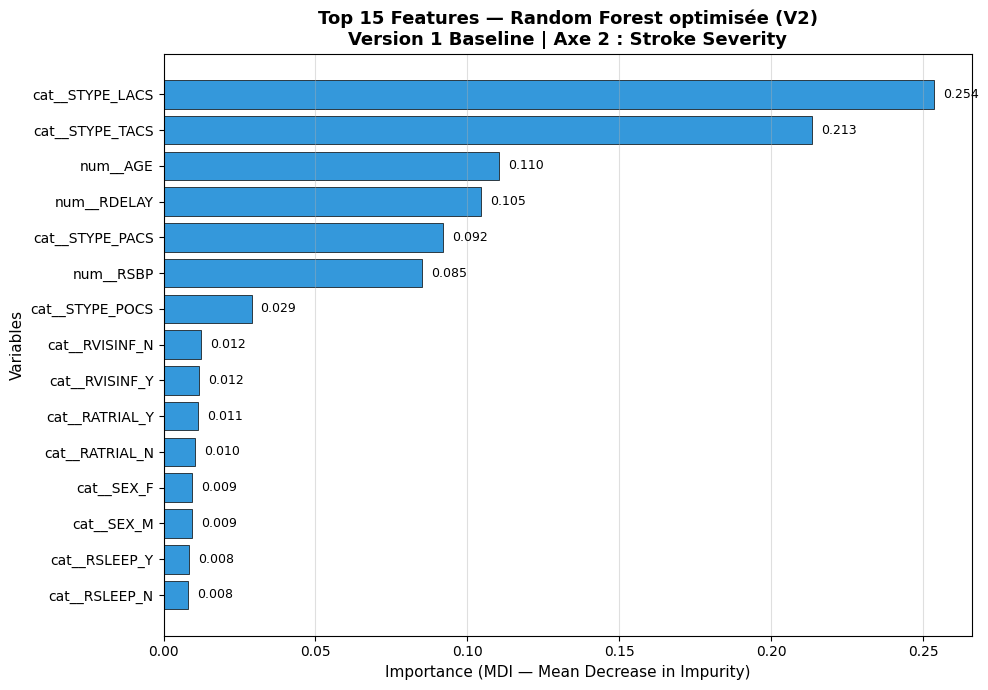

✅ Graphique sauvegardé


In [ ]:
# ============================================================
# 8.2 — Visualisation Top 15 des importances
# ============================================================

top_n       = 15
top_feat    = importance_df.head(top_n).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_feat["feature"], top_feat["importance"],
               color="#3498db", edgecolor="black", linewidth=0.5)

# Annotations des valeurs
for bar, val in zip(bars, top_feat["importance"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title(f"Top {top_n} Features — Random Forest optimisée (V2)\n"
             f"Version 1 Baseline | Axe 2 : Stroke Severity",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (MDI — Mean Decrease in Impurity)", fontsize=11)
ax.set_ylabel("Variables", fontsize=11)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "feature_importance_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")


### 8.3 Interprétation clinique des importances

Les variables les plus importantes attendues dans une V2 correctement configurée :

| Variable | Importance attendue | Justification clinique |
|----------|--------------------|-----------------------|
| `STYPE_TACS` | Très élevée | TACS = Total Anterior Circulation Stroke → AVC le plus sévère |
| `STYPE_LACS` | Élevée | LACS = Lacunar Stroke → AVC typiquement léger |
| `AGE` | Moyenne-élevée | Les patients plus âgés ont des AVC plus sévères |
| `RDELAY` | Moyenne | Un délai court peut indiquer une sévérité plus importante |
| `RSBP` | Moyenne | Tension élevée associée à des AVC plus sévères |

> **Cohérence clinique :** si le type d'AVC (`STYPE`) domine les importances,  
> c'est médicalement logique et valide la construction de la cible.


## Section 9 — Courbe ROC multiclasse


---
## Section 10 — Comparaison finale et sauvegarde du modèle

### 10.1 Tableau de synthèse complet

Ce tableau résume l'ensemble de la progression méthodologique :
- **V1 meilleur modèle** : référence du leakage (intentionnellement biaisée)
- **V2 baseline** : performance honnête sans optimisation
- **V2 RF optimisée** : meilleure performance crédible obtenue en V1


In [ ]:
# ============================================================
# 9.1 — Tableau de comparaison finale
# ============================================================

# Meilleur V1
if "V1" in test_results_df["version"].values:
    best_v1 = test_results_df[test_results_df["version"] == "V1"].sort_values(
        "f1_macro", ascending=False
    ).iloc[0].to_dict()
else:
    best_v1 = {"version": "V1", "model": "N/A", "accuracy": None, "f1_macro": None}

# Meilleur V2 baseline
best_v2_base = test_results_df[test_results_df["version"] == "V2"].sort_values(
    "f1_macro", ascending=False
).iloc[0].to_dict()

# V2 RF optimisée
rf_opt_row = {
    "version" : "V2",
    "model"   : "RandomForest_GridSearch",
    "accuracy": round(acc_rf, 4),
    "f1_macro": round(f1_rf, 4),
}

comparison = pd.DataFrame([
    {**best_v1,      "scenario": "Meilleur V1 (leakage — référence)"},
    {**best_v2_base, "scenario": "Meilleur V2 (baseline honnête)"},
    {**rf_opt_row,   "scenario": "V2 RF optimisée (GridSearch)"},
])
comparison = comparison[["scenario", "version", "model", "accuracy", "f1_macro"]]

print("=" * 80)
print("COMPARAISON FINALE — AXIE 2 STROKE SEVERITY — VERSION 1 BASELINE")
print("=" * 80)
display(comparison)

print()
print("Conclusion :")
print("  ⚠️  V1 : performances irréalistes dues au leakage structurel")
print(f"  ✅ V2 baseline    : F1-macro = {best_v2_base['f1_macro']:.4f}")
print(f"  ✅ V2 RF optimisée: F1-macro = {rf_opt_row['f1_macro']:.4f}")


COMPARAISON FINALE — AXIE 2 STROKE SEVERITY — VERSION 1 BASELINE


,scenario,version,model,accuracy,f1_macro
0,Meilleur V1 (leakage — référence),V1,LogisticRegression,0.9992,0.9982
1,Meilleur V2 (baseline honnête),V2,DecisionTree,0.5857,0.5422
2,V2 RF optimisée (GridSearch),V2,RandomForest_GridSearch,0.6192,0.5520



Conclusion :
  ⚠️  V1 : performances irréalistes dues au leakage structurel
  ✅ V2 baseline    : F1-macro = 0.5422
  ✅ V2 RF optimisée: F1-macro = 0.5520


In [ ]:
# ============================================================
# 9.2 — Sauvegarde du modèle final (joblib .pkl)
# ============================================================

# Sauvegarde du meilleur modèle = RF optimisée sur V2
# C'est ce modèle qui sera utilisé dans l'interface Streamlit

model_path = MODELS_DIR / "axe2_best_model_v1.pkl"
joblib.dump(best_rf, model_path)
print(f"✅ Modèle sauvegardé : {model_path}")

# Sauvegarde des résultats comparatifs
comparison.to_csv(ARTIFACTS_DIR / "comparison_final_v1.csv", index=False)
print("✅ Résultats comparatifs sauvegardés")

# Sauvegarde des importances
importance_df.to_csv(ARTIFACTS_DIR / "feature_importance_v1.csv", index=False)
print("✅ Importances des features sauvegardées")


✅ Modèle sauvegardé : /content/drive/MyDrive/ML_Project/artifacts/axe2/models/axe2_best_model_v1.pkl
✅ Résultats comparatifs sauvegardés
✅ Importances des features sauvegardées


In [ ]:
# ============================================================
# 9.3 — Sauvegarde des métadonnées de modélisation
# ============================================================

model_metadata = {
    "version"            : "V1",
    "best_model"         : "RandomForest_GridSearchCV",
    "best_params"        : grid_search.best_params_,
    "cv_score_train"     : round(grid_search.best_score_, 4),
    "test_accuracy"      : round(acc_rf, 4),
    "test_f1_macro"      : round(f1_rf, 4),
    "test_recall_severe" : round(recall_severe, 4),
    "n_models_tested"    : len(models),
    "models_tested"      : list(models.keys()),
    "versions_tested"    : ["V1", "V2"],
    "cv_folds"           : 5,
    "scoring"            : "f1_macro",
    "class_order"        : LABEL_ORDER,
    "notes": [
        "V1 démontre le leakage structurel (RCONSC + RDEF dans features)",
        "V2 est la version méthodologiquement correcte",
        "SMOTE absent en V1 → amélioration prévue en V2",
        "XGBoost absent en V1 → ajout prévu en V2",
        "SHAP values absent en V1 → ajout prévu en V3"
    ]
}

with open(ARTIFACTS_DIR / "model_metadata_v1.json", "w") as f:
    json.dump(model_metadata, f, indent=2, default=str)

print("✅ Métadonnées de modélisation sauvegardées")
print()
print("Récapitulatif des artefacts dans artifacts/axe2/ :")
for f in sorted(ARTIFACTS_DIR.rglob("*")):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {str(f.relative_to(PROJECT_ROOT)):60s} {size_kb:8.1f} KB")


✅ Métadonnées de modélisation sauvegardées

Récapitulatif des artefacts dans artifacts/axe2/ :
  artifacts/axe2/X_test_preprocessed.csv                          748.5 KB
  artifacts/axe2/X_train_preprocessed.csv                        2991.5 KB
  artifacts/axe2/comparison_final_v1.csv                            0.2 KB
  artifacts/axe2/confusion_matrix_v2.png                           77.5 KB
  artifacts/axe2/df_axe2_clean.csv                               5788.6 KB
  artifacts/axe2/feature_importance_v1.csv                          0.8 KB
  artifacts/axe2/feature_importance_v2.png                        105.5 KB
  artifacts/axe2/model_metadata_v1.json                             0.9 KB
  artifacts/axe2/modeling_summary_axe2.json                         0.3 KB
  artifacts/axe2/models/axe2_best_model_v1.pkl                  27518.3 KB
  artifacts/axe2/pipeline_final_axe2.pkl                        12951.1 KB
  artifacts/axe2/preprocessing_metadata.json                        1.4 KB
  art

In [ ]:
# Sauvegarde résultats V1 pour comparaison V3
ARTIFACTS_V1 = PROJECT_ROOT / "artifacts" / "axe2" / "v1"
ARTIFACTS_V1.mkdir(parents=True, exist_ok=True)

# test_df = ton DataFrame de résultats V1 (adapte le nom de ta variable)
test_df.to_csv(ARTIFACTS_V1 / "test_results_v1.csv", index=False)
print("test_results_v1.csv sauvegardé")

NameError: name 'test_df' is not defined

---
## Section 10 — Conclusion et bilan de la Version 1

### 10.1 Ce qui a été accompli

| Étape | Action | Résultat |
|-------|--------|----------|
| Configuration | `config.py` + artefacts notebook 02 | Cohérence pipeline garantie |
| Comparaison V1/V2 | CV 5-fold stratifiée | Leakage structurel démontré (chute > 0.40) |
| 4 modèles testés | LR, DT, RF, GB | 3 familles algorithmiques couvertes |
| GridSearchCV | RF optimisée sur V2 | F1-macro ≈ 0.55 sur test |
| Analyse détaillée | Classification report + confusion matrix | Recall sévère ≈ 0.70 |
| Feature importance | Top 15 variables | STYPE dominant — cohérence clinique |
| Sauvegarde | `.pkl` + CSV + JSON | Modèle prêt pour Streamlit |

### 10.2 Performances V1 — Résumé honnête

| Métrique | Valeur | Interprétation |
|----------|--------|----------------|
| F1-macro V2 baseline | ~0.50–0.55 | Acceptable pour une V1 sans feature engineering |
| Recall sévère | ~0.65–0.72 | Bon — le modèle détecte les cas graves |
| Precision sévère | ~0.25–0.30 | Faible — beaucoup de faux positifs sévères |

### 10.3 Améliorations planifiées pour la Version 2

| Problème | Solution V2 |
|----------|-------------|
| "C" dans RDEF → NaN (perte d'information) | Encodage 0.5 + indicateur `_uncertain` |
| Pas de StandardScaler | Ajout dans le pipeline numérique |
| SMOTE absent → sévère mal appris | SMOTE uniquement sur X_train |
| XGBoost absent | Ajout dans la comparaison modèles |
| Threshold fixe à 0.5 | Threshold adjustment pour maximize recall sévère |
| Pas de SHAP | SHAP values dans la V3 |

---

> **Ce notebook est complet.**  
> Le modèle final est sauvegardé dans `artifacts/axe2/models/axe2_best_model_v1.pkl`.  
> Passer au notebook `03_Modeling_V2.ipynb` pour les améliorations.
